In [1]:
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import os

In [2]:
import sys
sys.path.append("utils")
from torch_utils import *

In [3]:
model = fusion_v2()
trained_model = fusion_v2()

In [14]:
torch.cuda.empty_cache()

In [28]:
def show_normalized_image(img):
    """
    img: torch tensor (3, H, W), normalized using ImageNet mean/std.
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    # Unnormalize
    img_unnorm = img * std + mean
    img_unnorm = img_unnorm.clamp(0, 255).type(torch.uint8)  # keep values in valid range

    # Convert to numpy for plt
    img_np = img_unnorm.permute(1, 2, 0).numpy()

    img_np = np.ascontiguousarray(img_np)

    return img_np

In [5]:
trained_model.load_state_dict(torch.load("11weight.pt", weights_only=True))

<All keys matched successfully>

In [6]:
ds_path = "dataset/OPA/new_OPA/"
dataset_path = ds_path
label_dir = dataset_path + "new_alt_test_label.csv"
img_dir = dataset_path + "background"
obj_dir = dataset_path + "foreground"
transform = vit_transform

In [7]:
test_dataset = OPADataset_2(label_dir, img_dir, obj_dir, transform=transform, target_transform=None, obj_transform=transform)

In [8]:
test_dataloader = DataLoader(test_dataset, batch_size=5)

In [9]:
X,y,n = None,None,None
for X,y,n in test_dataloader:
    break

In [10]:
model.to(gpu)
trained_model.to(gpu)
model.eval()
trained_model.eval()
model_pred = model(X)
trained_pred = trained_model(X)

In [11]:
model_pred

tensor([[ -119.9347,   -87.3314,  -124.9103,   -77.3079],
        [  -76.4481,   -61.3541,   -34.9552,   -54.2208],
        [  -98.3534,  -218.9025,   -66.7009,   -46.1859],
        [ -285.3290, -1111.5757,  -199.7971,  -216.9403],
        [ -147.6469,  -155.9795,  -131.2493,   -60.0803]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [24]:
y[0][2][1].item() == float('inf')

True

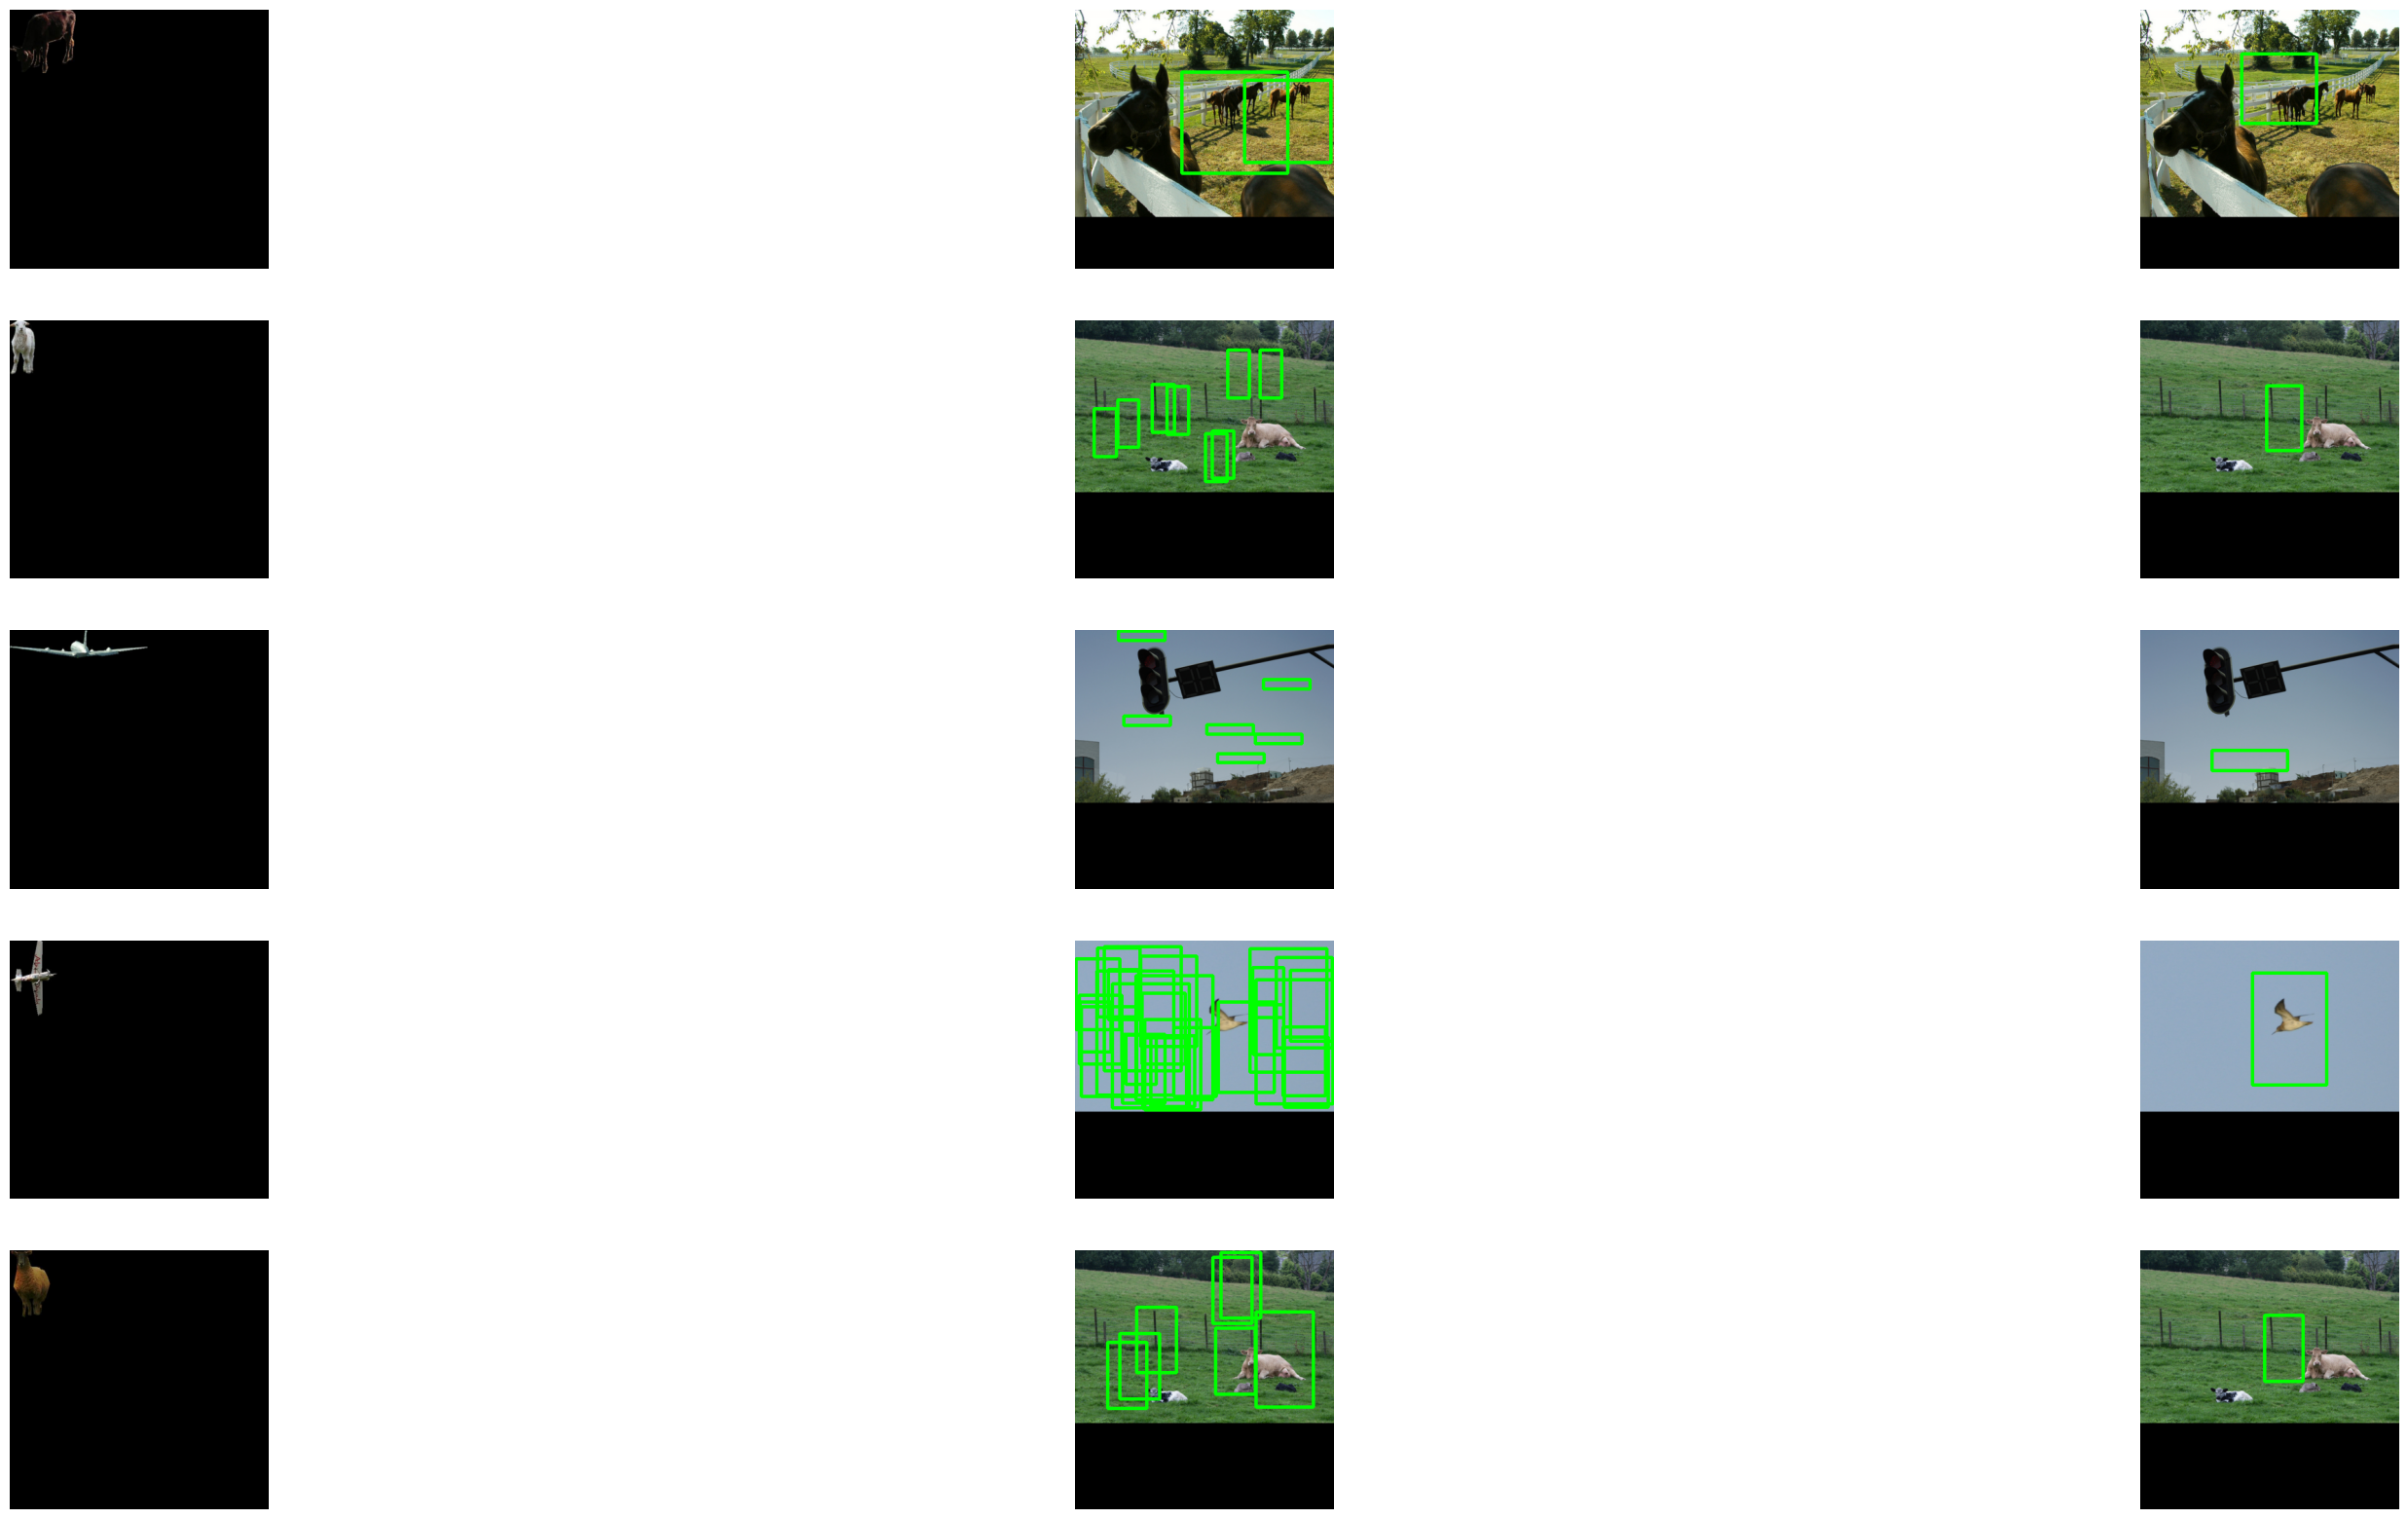

In [34]:
nrow = len(X)
ncol = 3
idx = 0

fig, axis = plt.subplots(nrow,ncol,figsize=(40,20))
for i in range(len(X)):
    fg_n, bg_n = n[i].split("c")
    fg_img = X[i][3:, :, :]
    bg_img = X[i][:3, :, :]    

    x = X[i]
    label = y[i]

    pred_img = bg_img[:,:,:]
    pred_img = show_normalized_image(pred_img.cpu())
    label_img = show_normalized_image(bg_img.cpu())
    fg_img = show_normalized_image(fg_img.cpu())

    for each_label in label:
        xmin = each_label[0].item()
        ymin = each_label[1].item()
        xmax = each_label[2].item()
        ymax = each_label[3].item()
        if xmin == float('inf'):
            break
        xmin,ymin,xmax,ymax = [int(x) for x in [xmin,ymin,xmax,ymax]]
        label_img = cv2.rectangle(label_img,(xmin,ymax),(xmax,ymin),(0,255,0),3)

    pred = trained_pred[i]
    
    xmin = pred[0].item()
    ymin = pred[1].item()
    xmax = pred[2].item()
    ymax = pred[3].item()
    xmin,ymin,xmax,ymax = [int(x) for x in [xmin,ymin,xmax,ymax]]
    pred_img = cv2.rectangle(pred_img,(xmin,ymax),(xmax,ymin),(0,255,0),3)
    
    #bg_img = bg_img.cpu().type(torch.uint8).permute(1, 2, 0).numpy()
    #fg_img = fg_img.cpu().type(torch.uint8).permute(1, 2, 0).numpy()

    idx += 1
    plt.subplot(nrow, ncol, idx)
    plt.axis("off")
    plt.imshow(fg_img)

    idx += 1
    plt.subplot(nrow, ncol, idx)
    plt.axis("off")
    plt.imshow(label_img)

    idx += 1
    plt.subplot(nrow, ncol, idx)
    plt.axis("off")
    plt.imshow(pred_img)


In [36]:
b_vit = torchvision.models.vit_b_16(weights="IMAGENET1K_SWAG_E2E_V1") 

In [38]:
b_vit.heads = torch.nn.Identity()

In [43]:
dataset_path = ds_path
label_dir = dataset_path + "new_alt_test_label.csv"
img_dir = dataset_path + "background"
obj_dir = dataset_path + "foreground"
transform = vit_transform

In [44]:
test_dataset = OPADataset(label_dir, img_dir, obj_dir, transform=transform, target_transform=None)

In [47]:
test_dataloader = DataLoader(test_dataset, batch_size=1)

In [52]:
for X,y,n in test_dataloader:
    X = X[:, :3, :, :]
    print(X.shape)
    pred = b_vit(X)
    break

torch.Size([1, 3, 384, 384])


In [65]:
pred.shape

torch.Size([1, 768])

In [37]:
b_vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [34]:
obj_fe = torchvision.models.efficientnet_v2_s(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /home/jay/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100.0%


In [60]:
obj_fe

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [59]:
obj_fe.classifier = torch.nn.Identity()

In [62]:
obj_fe.to(gpu)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [69]:
for X,y,n in test_dataloader:
    X = X[:, :3, :, :]
    print(X.shape)
    fg_pred = obj_fe(X)
    break

torch.Size([1, 3, 384, 384])


In [75]:
X[0].shape

torch.Size([3, 384, 384])

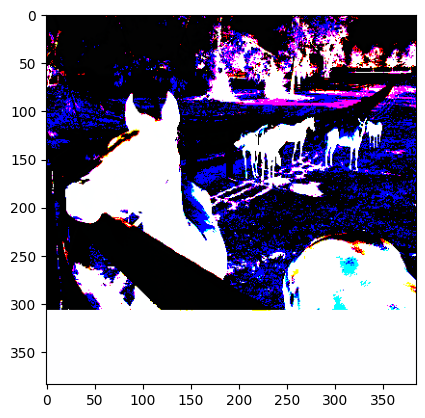

In [79]:
plt.imshow(X[0].cpu().type(torch.uint8).permute(1, 2, 0).numpy())

In [64]:
fg_pred.shape

torch.Size([1, 1280])

In [3]:
!ls dataset/OPA/new_OPA/

background	      lraspp.ipynb	       output
composite	      max		       readme.txt
create_label.ipynb    max.zip		       test.png
data_wrangling.ipynb  new_alt_test_label.csv   test_set.csv
density.ipynb	      new_alt_train_label.csv  train_set.csv
foreground	      new_test_label.csv       uniform
label.zip	      new_train_label.csv      weighted
lraspp_backup.ipynb   old_label


In [4]:
ds_path = "dataset/OPA/new_OPA/"

In [13]:
sample_fg_name = ["airplane/156417.jpg", "airplane/156529.jpg",
                  "apple/1047228.jpg", "banana/1041510.jpg",
                  "banana/1041620.jpg", "chair/101090.jpg"]

In [14]:
fg_imgs = []
for n in sample_fg_name:
    img_n = os.path.join(ds_path,"foreground",n)
    fg_imgs.append(decode_image(img_n).type(torch.float32))

In [29]:
resized_fg_imgs = [pad_to_n(torchvision.transforms.Resize((384,))(img),384) for img in fg_imgs]

In [19]:
def show_img(imgs):
    nrow = len(imgs)
    ncol = 1
    idx = 0
    fig, axes = plt.subplots(nrow, ncol, figsize=(10,10*nrow))
    for img in imgs:
        idx += 1
        img = img.type(torch.uint8).permute(1, 2, 0).numpy()
        plt.subplot(nrow, ncol, idx)
        plt.imshow(img)


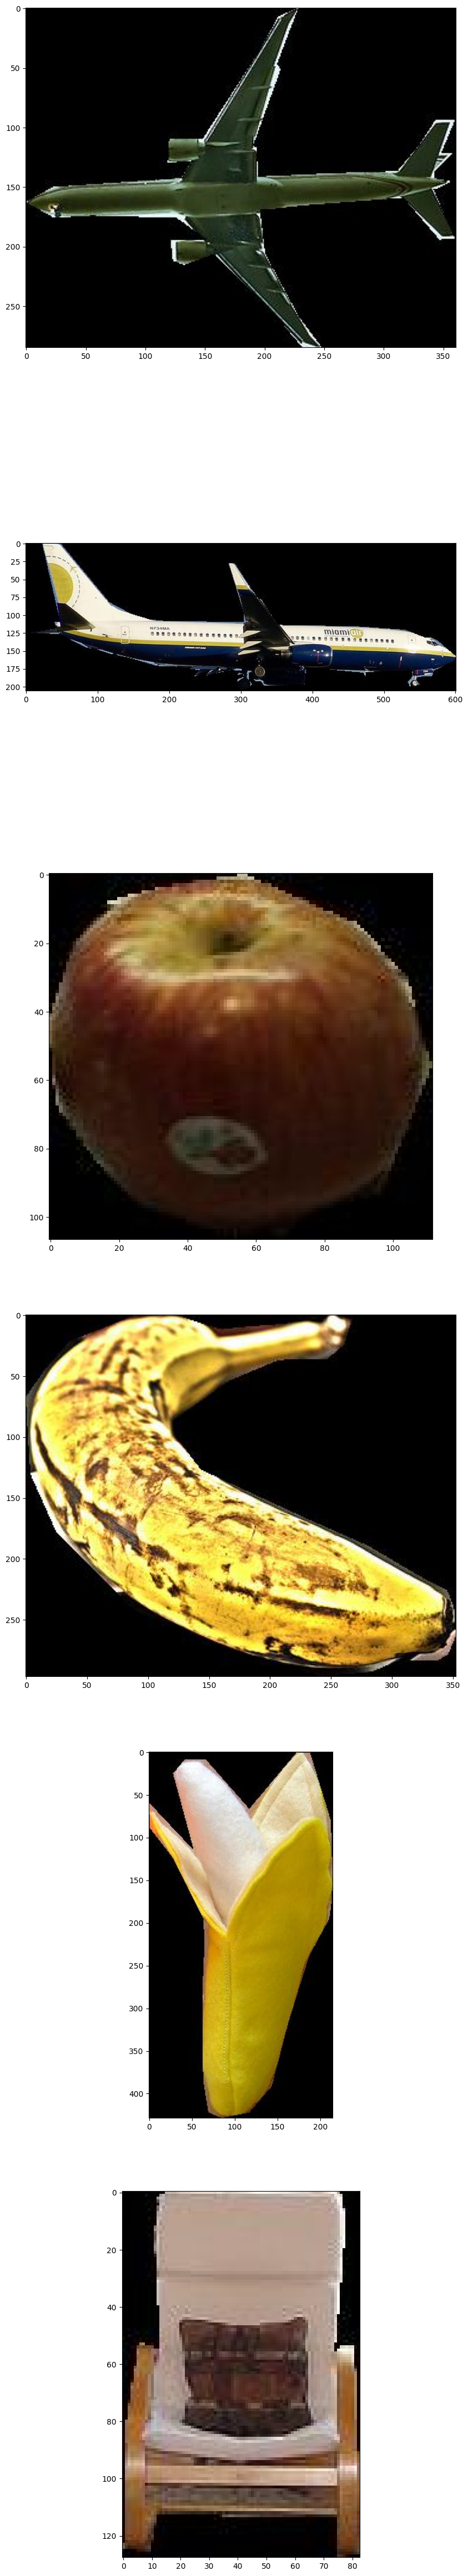

In [30]:
show_img(fg_imgs)

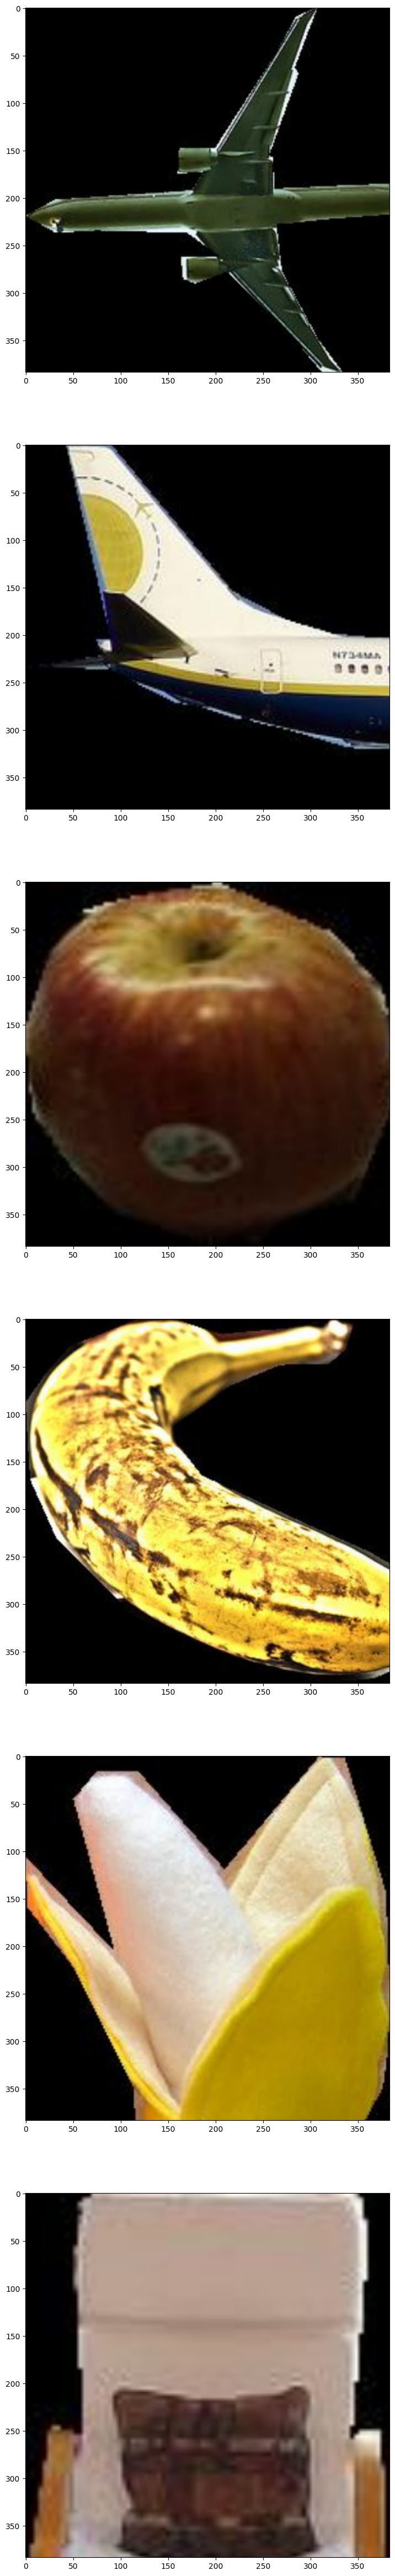

In [31]:
show_img(resized_fg_imgs)